# Tech Challenge Fase 4 — LSTM para Previsao de Acoes

**Acao:** ITUB4.SA (Itau Unibanco — B3)  
**Objetivo:** Prever o preco de fechamento usando redes neurais LSTM (PyTorch)  
**Pipeline:** Coleta -> Pre-processamento -> Modelo LSTM -> Avaliacao -> Salvamento

## 1. Configuracao e Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
print(f'Device: {"GPU" if torch.cuda.is_available() else "CPU"}')

from src.data.collector import load_or_download
from src.model.preprocessing import prepare_data, WINDOW_SIZE, scale_input, inverse_scale
from src.model.lstm import build_model, train_model, evaluate_model, save_model, load_model, predict_one

SYMBOL = 'ITUB4.SA'
START_DATE = '2018-01-01'
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('tab10')

PyTorch: 2.13.0+cpu
Device: CPU


## 2. Coleta e Analise Exploratoria dos Dados

In [2]:
df = load_or_download(SYMBOL, start_date=START_DATE, cache=True)
print(f'Periodo: {df.index[0].date()} ate {df.index[-1].date()}')
print(f'Total de registros: {len(df)}')
df.tail()

Periodo: 2018-01-02 ate 2026-07-28
Total de registros: 2130


Price,Close,Open,High,Low,Volume
Date,,,,,
2026-07-22,42.900002,42.680000,42.980000,42.270000,21986300
2026-07-23,42.560001,42.639999,42.869999,42.270000,22570600
2026-07-24,42.099998,42.299999,42.450001,42.040001,10443700
2026-07-27,42.689999,42.450001,42.860001,42.330002,14920100
2026-07-28,42.860001,43.500000,43.669998,42.599998,19076000


In [3]:
df.describe()

Price,Close,Open,High,Low,Volume
count,2130.000000,2130.000000,2130.000000,2130.000000,2.130000e+03
mean,22.106089,22.111152,22.364317,21.856572,3.218076e+07
std,7.507060,7.505065,7.552651,7.460204,1.654850e+07
min,12.782084,13.291570,13.388779,12.458171,0.000000e+00
25%,17.155606,17.186445,17.402424,16.925910,2.066785e+07
50%,19.562652,19.561577,19.814867,19.319282,2.820218e+07
75%,24.573268,24.525574,24.754156,24.303441,3.996258e+07
max,48.425404,48.111528,48.719663,47.670136,1.820390e+08


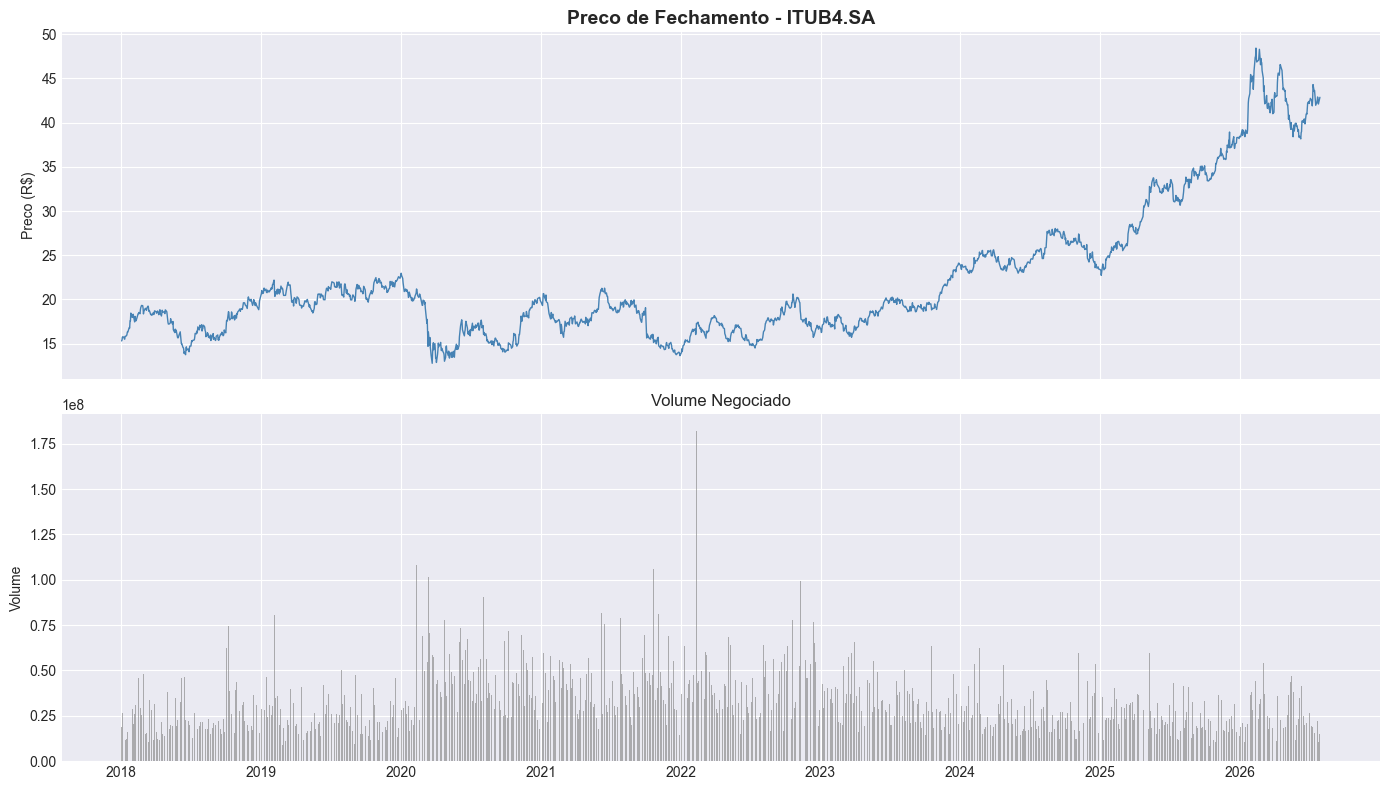

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_title(f'Preco de Fechamento - {SYMBOL}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Preco (R$)')

axes[1].bar(df.index, df['Volume'], color='gray', alpha=0.6)
axes[1].set_title('Volume Negociado', fontsize=12)
axes[1].set_ylabel('Volume')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../reports/figures/price_volume.png', dpi=150, bbox_inches='tight')
plt.show()

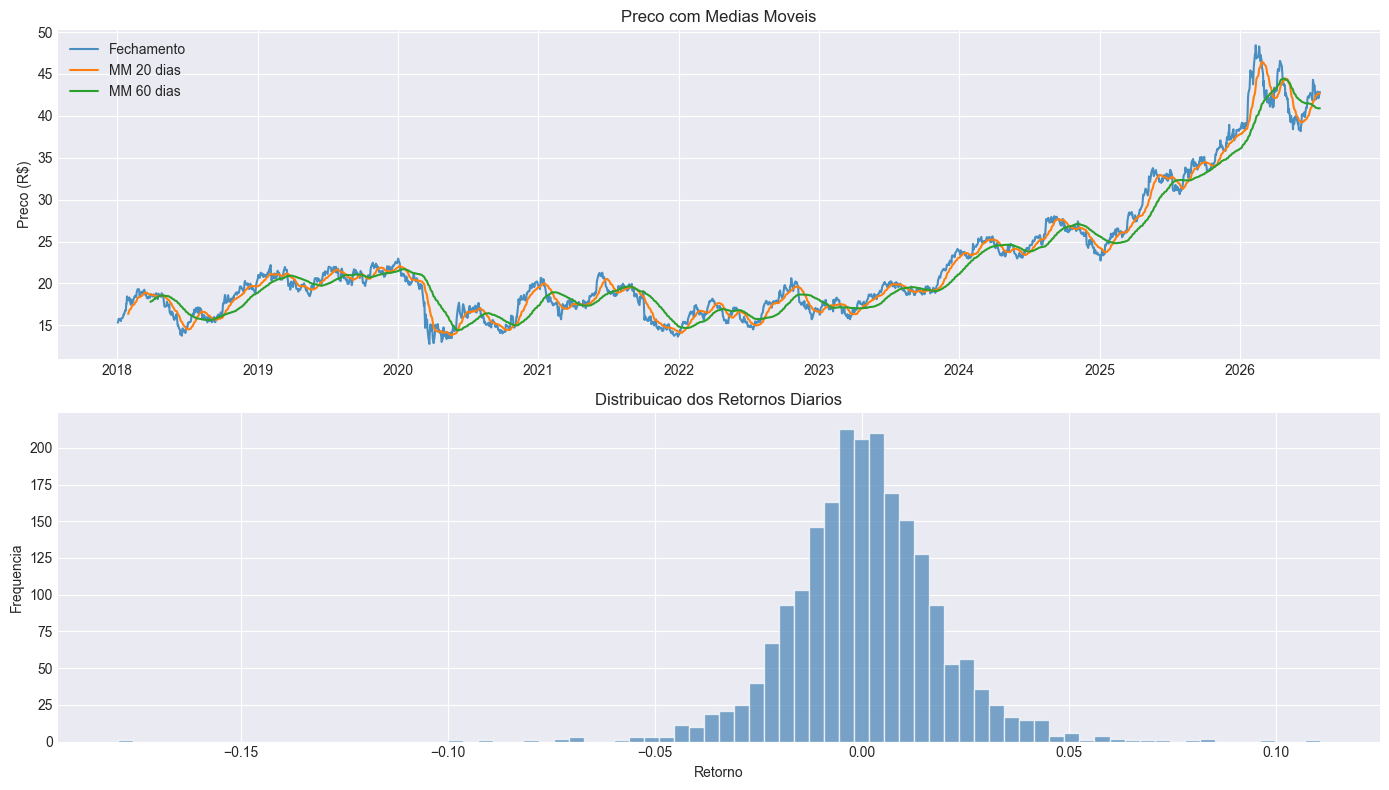

In [5]:
df['retorno_diario'] = df['Close'].pct_change()
df['media_movel_20'] = df['Close'].rolling(20).mean()
df['media_movel_60'] = df['Close'].rolling(60).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, df['Close'], label='Fechamento', alpha=0.8)
axes[0].plot(df.index, df['media_movel_20'], label='MM 20 dias', linewidth=1.5)
axes[0].plot(df.index, df['media_movel_60'], label='MM 60 dias', linewidth=1.5)
axes[0].legend()
axes[0].set_title('Preco com Medias Moveis')
axes[0].set_ylabel('Preco (R$)')

axes[1].hist(df['retorno_diario'].dropna(), bins=80, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_title('Distribuicao dos Retornos Diarios')
axes[1].set_xlabel('Retorno')
axes[1].set_ylabel('Frequencia')

plt.tight_layout()
plt.savefig('../reports/figures/moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pre-processamento e Criacao das Sequencias

In [6]:
X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_data(df, window=WINDOW_SIZE)

print(f'Janela temporal: {WINDOW_SIZE} dias')
print(f'Treino:  X={X_train.shape}  y={y_train.shape}')
print(f'Val:     X={X_val.shape}    y={y_val.shape}')
print(f'Teste:   X={X_test.shape}   y={y_test.shape}')

Janela temporal: 60 dias
Treino:  X=(1431, 60, 1)  y=(1431,)
Val:     X=(319, 60, 1)    y=(319,)
Teste:   X=(320, 60, 1)   y=(320,)


## 4. Construcao e Treinamento do Modelo LSTM

In [7]:
model = build_model()
print(model)

LSTMModel(
  (lstm1): LSTM(1, 128, batch_first=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(128, 64, batch_first=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [8]:
history = train_model(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=32)

Epoch   1/100 | loss=0.006996 | val_loss=0.037623 | val_mae=0.189640


Epoch  10/100 | loss=0.000431 | val_loss=0.000556 | val_mae=0.019946


Epoch  20/100 | loss=0.000288 | val_loss=0.000346 | val_mae=0.015431


EarlyStopping na época 25.


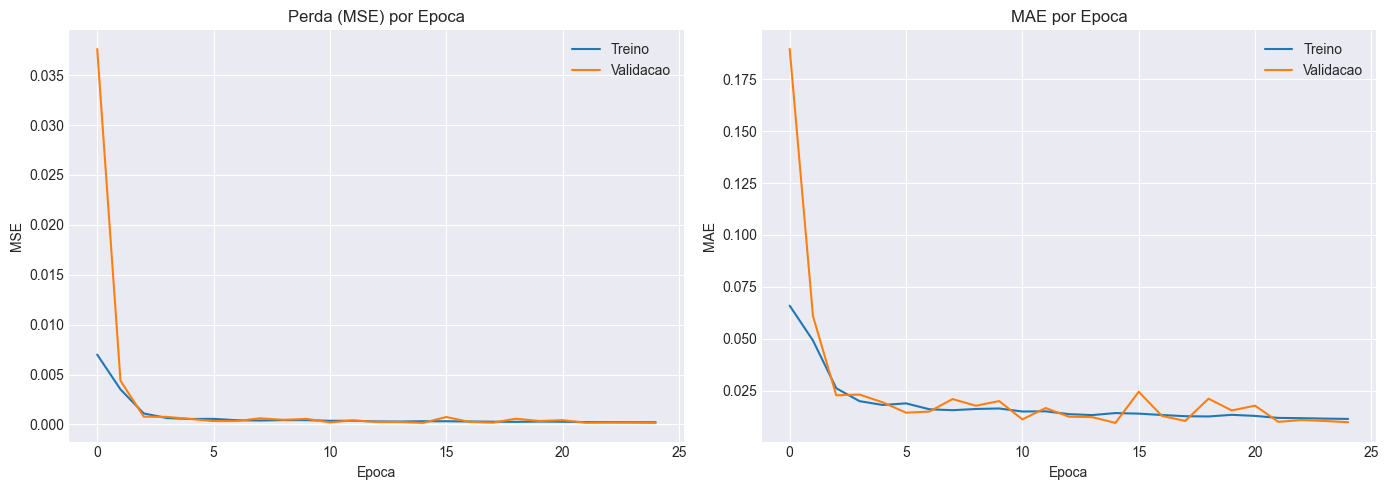

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['loss'], label='Treino')
axes[0].plot(history['val_loss'], label='Validacao')
axes[0].set_title('Perda (MSE) por Epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history['mae'], label='Treino')
axes[1].plot(history['val_mae'], label='Validacao')
axes[1].set_title('MAE por Epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Avaliacao do Modelo

In [10]:
metrics, y_true, y_pred = evaluate_model(model, X_test, y_test, scaler)

print('=' * 40)
print('METRICAS NO CONJUNTO DE TESTE')
print('=' * 40)
print(f"MAE:  R$ {metrics['MAE']:.4f}")
print(f"RMSE: R$ {metrics['RMSE']:.4f}")
print(f"MAPE: {metrics['MAPE']:.2f}%")

METRICAS NO CONJUNTO DE TESTE
MAE:  R$ 0.7559
RMSE: R$ 1.0137
MAPE: 1.96%


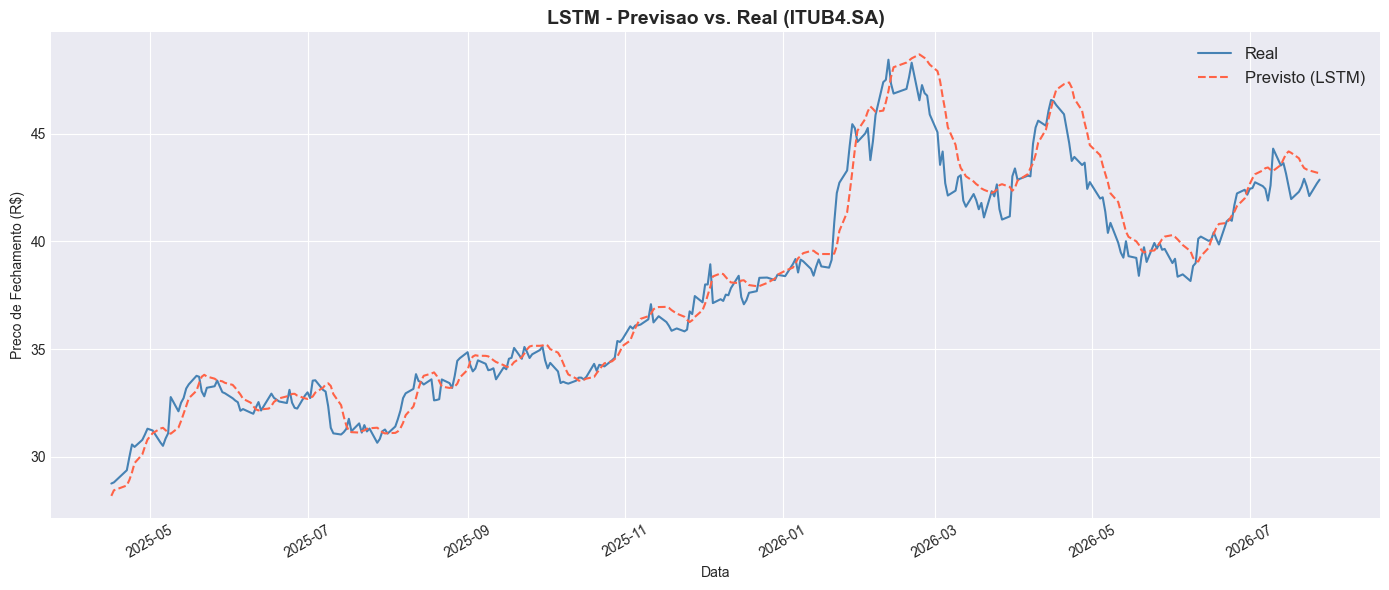

In [11]:
n_test = len(df) - len(X_test)
test_dates = df.index[n_test : n_test + len(X_test)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, y_true, label='Real', color='steelblue', linewidth=1.5)
ax.plot(test_dates, y_pred, label='Previsto (LSTM)', color='tomato', linewidth=1.5, linestyle='--')
ax.set_title(f'LSTM - Previsao vs. Real ({SYMBOL})', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Preco de Fechamento (R$)')
ax.legend(fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/figures/predictions_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

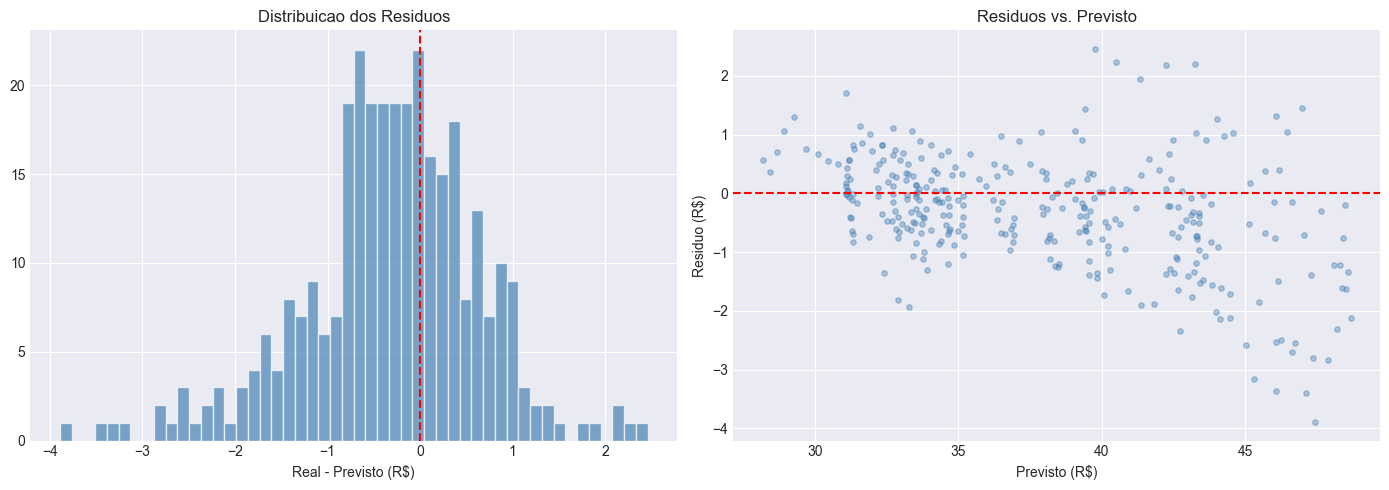

In [12]:
residuals = y_true.flatten() - y_pred.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribuicao dos Residuos')
axes[0].set_xlabel('Real - Previsto (R$)')

axes[1].scatter(y_pred, residuals, alpha=0.4, color='steelblue', s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuos vs. Previsto')
axes[1].set_xlabel('Previsto (R$)')
axes[1].set_ylabel('Residuo (R$)')

plt.tight_layout()
plt.savefig('../reports/figures/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Salvamento do Modelo

In [13]:
save_model(model, scaler, name='lstm_itub4')
print('Modelo salvo em models/lstm_itub4.pt')
print('Scaler salvo em models/lstm_itub4_scaler.joblib')

Modelo salvo em models/lstm_itub4.pt
Scaler salvo em models/lstm_itub4_scaler.joblib


## 7. Previsao dos Proximos Dias

In [14]:
model_loaded, scaler_loaded = load_model('lstm_itub4')

ultimos_60 = df['Close'].values[-WINDOW_SIZE:].flatten().tolist()
X_input = scale_input(ultimos_60, scaler_loaded)
pred_scaled = predict_one(model_loaded, X_input)
pred_preco = inverse_scale(pred_scaled, scaler_loaded)

print(f'Ultimo preco real:    R$ {df["Close"].iloc[-1]:.2f}')
print(f'Previsao proximo dia: R$ {pred_preco:.2f}')

Ultimo preco real:    R$ 42.86
Previsao proximo dia: R$ 43.23


In [15]:
previsoes = []
window = list(ultimos_60)

for i in range(5):
    X_input = scale_input(window[-WINDOW_SIZE:], scaler_loaded)
    pred_s = predict_one(model_loaded, X_input)
    pred_v = inverse_scale(pred_s, scaler_loaded)
    previsoes.append(pred_v)
    window.append(pred_v)

print('Previsoes para os proximos 5 dias uteis:')
for i, p in enumerate(previsoes, 1):
    print(f'  Dia {i}: R$ {p:.2f}')

Previsoes para os proximos 5 dias uteis:
  Dia 1: R$ 43.23
  Dia 2: R$ 43.38
  Dia 3: R$ 43.59
  Dia 4: R$ 43.83
  Dia 5: R$ 44.09
